# EXPT NO: 6B
# DATA VISUALIZATION USING POWER BI (ADVANCED IPL ANALYTICS)

## Aim
To load the IPL ball-by-ball data into Power BI, transform the data, create calculated fields, and visualize it to obtain useful insights.

This experiment follows the advanced Power BI workflow from the lab reference and adapts its retail-sales fields to the IPL dataset.

## Algorithm
1. Open Power BI Desktop.
2. Import the IPL CSV using **Home → Get Data → Text/CSV** and load it.
3. Open **Transform Data / Power Query**.
4. Remove duplicates and handle null values.
5. Parse the `start_date` field as a date and format relevant columns.
6. Create calculated fields such as total runs, boundary runs, and wicket indicators.
7. Create line, bar/column, and donut/pie visuals.
8. Add slicers for season/team/date in the Power BI report.
9. Save the Power BI report as a `.pbix` file.

The reference experiment specifically includes import, Power Query transformation, date parsing, calculated fields, dashboard visuals and slicers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

file_path = 'IPL_ball_by_ball_updated.csv'
df = pd.read_csv(file_path)
print('Dataset loaded successfully.')
print('Shape:', df.shape)
df.head()

Dataset loaded successfully.
Shape: (243815, 22)


,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,P Kumar,0,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Importing and verifying the data
The dataset is checked for dimensions, columns and data types before transformation.

In [2]:
print('Columns:')
print(df.columns.tolist())
print('\nData types:')
print(df.dtypes)

Columns:
['match_id', 'season', 'start_date', 'venue', 'innings', 'ball', 'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed']

Data types:
match_id                    int64
season                      int64
start_date                 object
venue                      object
innings                     int64
ball                      float64
batting_team               object
bowling_team               object
striker                    object
non_striker                object
bowler                     object
runs_off_bat                int64
extras                      int64
wides                     float64
noballs                   float64
byes                      float64
legbyes                   float64
penalty                   float64
wicket_type                object
player_dismissed           object
other_w

## 2. Power Query-style data transformation
The following Python steps reproduce the main preparation operations that can be performed in Power Query: duplicate removal, date parsing, and handling sparse optional fields.

In [3]:
before = len(df)
df = df.drop_duplicates().copy()
print('Duplicate rows removed:', before - len(df))

df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
print('Invalid dates after parsing:', df['start_date'].isna().sum())

sparse_columns = ['wides', 'noballs', 'byes', 'legbyes', 'penalty']
for col in sparse_columns:
    df[col] = df[col].fillna(0)

df['wicket_type'] = df['wicket_type'].fillna('No Wicket')
df['player_dismissed'] = df['player_dismissed'].fillna('No Dismissal')

print('\nTransformed data preview:')
df.head()

Duplicate rows removed: 0
Invalid dates after parsing: 0



Transformed data preview:


,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,P Kumar,0,1,0.0,0.0,0.0,1.0,0.0,No Wicket,No Dismissal,NaN,NaN
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,0.0,0.0,0.0,0.0,0.0,No Wicket,No Dismissal,NaN,NaN
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,1,1.0,0.0,0.0,0.0,0.0,No Wicket,No Dismissal,NaN,NaN
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,0.0,0.0,0.0,0.0,0.0,No Wicket,No Dismissal,NaN,NaN
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,0.0,0.0,0.0,0.0,0.0,No Wicket,No Dismissal,NaN,NaN


## 3. Advanced transformation and calculated fields
IPL does not contain the retail `Quantity`, `UnitPrice`, or `Discount` fields used in the reference experiment. Equivalent sports-analytics calculated fields are created instead.

In [4]:
df['total_runs'] = df['runs_off_bat'] + df['extras']
df['boundary_runs'] = np.where(df['runs_off_bat'].isin([4, 6]), df['runs_off_bat'], 0)
df['is_boundary'] = df['runs_off_bat'].isin([4, 6]).astype(int)
df['is_wicket'] = (df['wicket_type'] != 'No Wicket').astype(int)

print(df[['runs_off_bat', 'extras', 'total_runs', 'boundary_runs', 'is_boundary', 'is_wicket']].head(12))

    runs_off_bat  extras  total_runs  boundary_runs  is_boundary  is_wicket
0              0       1           1              0            0          0
1              0       0           0              0            0          0
2              0       1           1              0            0          0
3              0       0           0              0            0          0
4              0       0           0              0            0          0
5              0       0           0              0            0          0
6              0       1           1              0            0          0
7              0       0           0              0            0          0
8              4       0           4              4            1          0
9              4       0           4              4            1          0
10             6       0           6              6            1          0
11             4       0           4              4            1          0


## 4. Core calculated metrics

In [5]:
total_runs = int(df['total_runs'].sum())
total_matches = int(df['match_id'].nunique())
total_deliveries = int(len(df))
total_boundaries = int(df['is_boundary'].sum())
total_wickets = int(df['is_wicket'].sum())

metrics = pd.DataFrame({
    'Metric': ['Total Runs', 'Total Matches', 'Total Deliveries', 'Boundary Deliveries', 'Wicket Deliveries'],
    'Value': [total_runs, total_matches, total_deliveries, total_boundaries, total_wickets]
})
metrics

,Metric,Value
0,Total Runs,321784
1,Total Matches,1024
2,Total Deliveries,243815
3,Boundary Deliveries,39465
4,Wicket Deliveries,12067


## 5. Line chart – runs by season

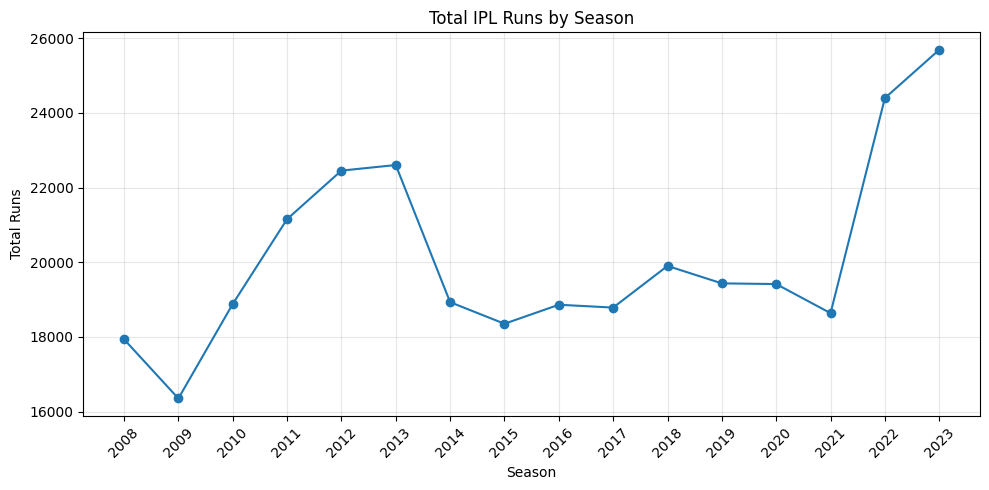

In [6]:
season_runs = df.groupby('season', as_index=False)['total_runs'].sum()
plt.figure(figsize=(10,5))
plt.plot(season_runs['season'], season_runs['total_runs'], marker='o')
plt.title('Total IPL Runs by Season')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.xticks(season_runs['season'], rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Bar chart – top batting teams by runs

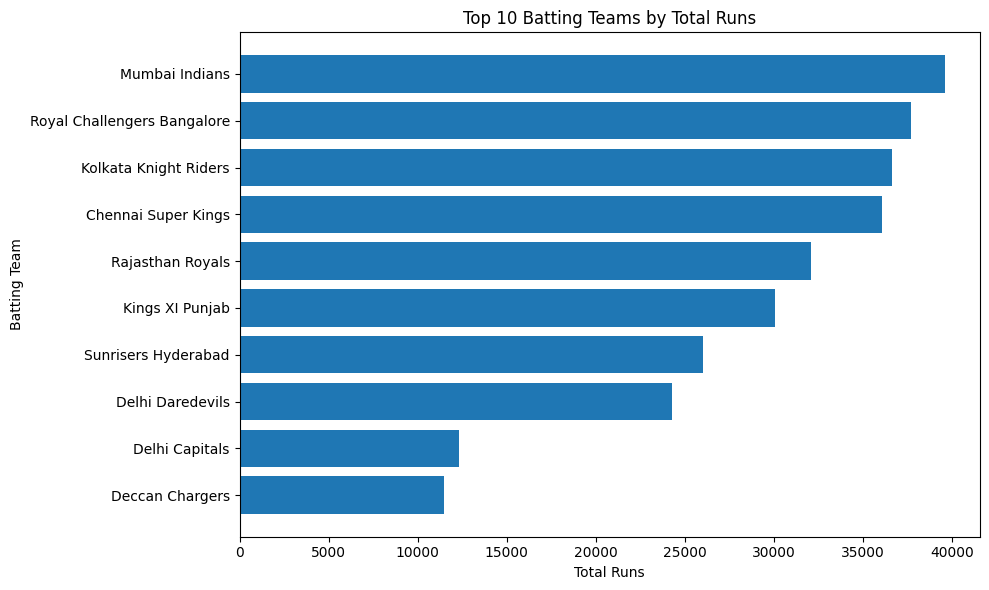

In [7]:
team_runs = df.groupby('batting_team', as_index=False)['total_runs'].sum().sort_values('total_runs', ascending=False).head(10)
plt.figure(figsize=(10,6))
plt.barh(team_runs['batting_team'][::-1], team_runs['total_runs'][::-1])
plt.title('Top 10 Batting Teams by Total Runs')
plt.xlabel('Total Runs')
plt.ylabel('Batting Team')
plt.tight_layout()
plt.show()

## 7. Donut-style pie chart – wicket types

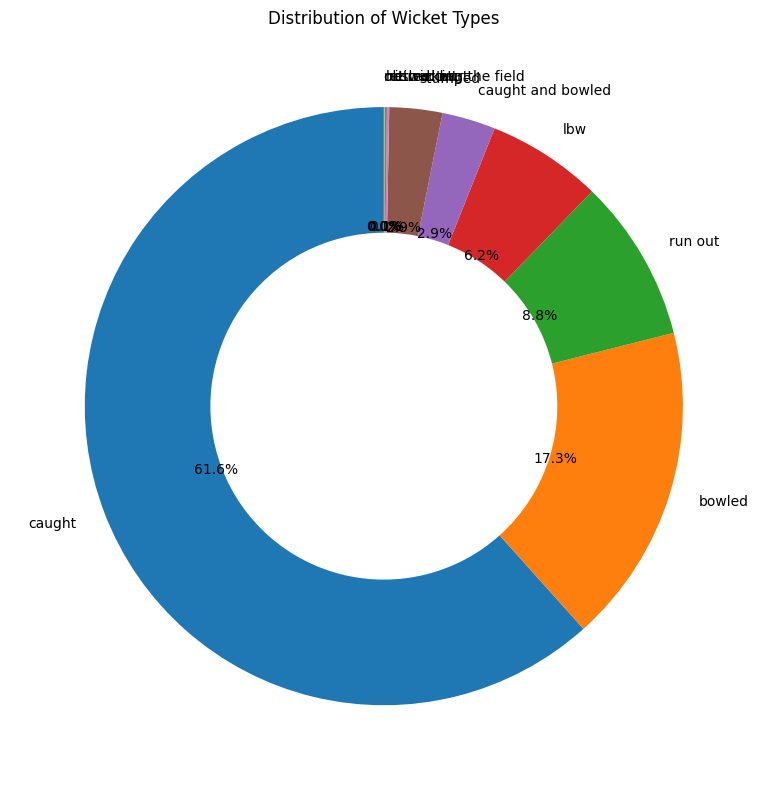

In [8]:
wicket_counts = df.loc[df['is_wicket'] == 1, 'wicket_type'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(wicket_counts.values, labels=wicket_counts.index, autopct='%1.1f%%', startangle=90, wedgeprops={'width': 0.42})
plt.title('Distribution of Wicket Types')
plt.tight_layout()
plt.show()

## 8. Date-based analysis for the Power BI line visual

In [9]:
daily_runs = (df.dropna(subset=['start_date'])
              .groupby('start_date', as_index=False)['total_runs'].sum()
              .sort_values('start_date'))
print('Date range:', daily_runs['start_date'].min().date(), 'to', daily_runs['start_date'].max().date())
print('Number of match dates:', daily_runs['start_date'].nunique())
print('\nHighest run-producing dates:')
print(daily_runs.nlargest(10, 'total_runs').to_string(index=False))

Date range: 2008-04-18 to 2023-05-29
Number of match dates: 762

Highest run-producing dates:
start_date  total_runs
2023-05-07         829
2018-05-12         827
2023-04-30         827
2018-04-15         805
2023-05-21         796
2023-04-23         792
2019-04-28         788
2022-05-01         775
2022-03-27         769
2008-05-24         767


## 9. DAX measures for the Power BI report
These are examples to enter in Power BI after loading the IPL table.

In [10]:
dax_measures = {
    'Total Runs': 'Total Runs = SUM(IPL[runs_off_bat])',
    'Total Matches': 'Total Matches = DISTINCTCOUNT(IPL[match_id])',
    'Total Deliveries': 'Total Deliveries = COUNTROWS(IPL)',
    'Total Wickets': 'Total Wickets = CALCULATE(COUNTROWS(IPL), IPL[wicket_type] <> BLANK())',
    'Boundary Runs': 'Boundary Runs = CALCULATE(SUM(IPL[runs_off_bat]), IPL[runs_off_bat] IN {4, 6})'
}
for name, formula in dax_measures.items():
    print(name + ':')
    print(formula + '\n')

Total Runs:
Total Runs = SUM(IPL[runs_off_bat])

Total Matches:
Total Matches = DISTINCTCOUNT(IPL[match_id])

Total Deliveries:
Total Deliveries = COUNTROWS(IPL)

Total Wickets:
Total Wickets = CALCULATE(COUNTROWS(IPL), IPL[wicket_type] <> BLANK())

Boundary Runs:
Boundary Runs = CALCULATE(SUM(IPL[runs_off_bat]), IPL[runs_off_bat] IN {4, 6})



## 10. Dashboard design in Power BI
Recommended visuals following the reference workflow:
- **Line chart:** `start_date` or `season` vs `Total Runs`.
- **Bar/column chart:** `batting_team` vs `Total Runs`.
- **Donut chart:** `wicket_type` distribution.
- **Cards:** Total Runs, Total Matches, Total Deliveries, Total Wickets.
- **Slicers:** Season, Batting Team, Bowling Team, Venue, and Start Date.

The actual interactive dashboard and `.pbix` file should be created in Power BI Desktop.

## Result
The IPL ball-by-ball dataset was imported, transformed, date-parsed, and extended with calculated fields. Dashboard-oriented line, bar, and donut visualizations were generated, and DAX measures were prepared for implementation in Power BI.